# Generated Molecule Count Distribution

A compact notebook to inspect how many generated molecules each row contains.
Change the config cell below to point at a different dataset folder or list column.


In [1]:
import importlib.util

required_packages = ["matplotlib", "numpy", "pandas"]
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]

if missing_packages:
    print("Install missing packages with:")
    print("%pip install -U " + " ".join(required_packages))
    print("Missing:", missing_packages)
else:
    print("Packages OK")


Packages OK


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
assert (PROJECT_ROOT / "src").exists(), "Run this notebook from the Thesis repo root or from notebooks/."

plt.style.use("seaborn-v0_8-whitegrid")

DATASET_DIR = PROJECT_ROOT / "data" / "big_post_training" / "grouped_splits"
FILE_PATTERN = "*.jsonl"
MOLECULE_LIST_COLUMN = "target_selfies_list"

FIGSIZE_OVERALL = (10, 4)
FIGSIZE_SPLIT = (10, 4)
SUMMARY_PERCENTILES = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]


def infer_split_name(path: Path) -> str:
    stem = path.stem.lower()
    if "train" in stem:
        return "train"
    if "validation" in stem or "valid" in stem or "val" in stem:
        return "validation"
    if "test" in stem:
        return "test"
    return path.stem


def sort_split_names(names) -> list[str]:
    order = {"train": 0, "validation": 1, "test": 2}
    return sorted(names, key=lambda name: (order.get(str(name), 99), str(name)))


def discover_split_files(dataset_dir: Path, file_pattern: str) -> list[Path]:
    dataset_dir = dataset_dir.resolve()
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory does not exist: {dataset_dir}")

    split_files = sorted(path for path in dataset_dir.glob(file_pattern) if path.is_file())
    if not split_files:
        raise FileNotFoundError(
            f"No files matched pattern {file_pattern!r} in dataset directory {dataset_dir}."
        )
    return split_files


def collect_length_records(split_files: list[Path], molecule_list_column: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows: list[dict] = []
    issues: list[dict] = []

    for path in split_files:
        split = infer_split_name(path)
        with path.open("r", encoding="utf-8") as handle:
            for line_number, line in enumerate(handle, start=1):
                try:
                    payload = json.loads(line)
                except json.JSONDecodeError as exc:
                    issues.append(
                        {
                            "split": split,
                            "source_file": path.name,
                            "line_number": line_number,
                            "issue": "invalid_json",
                            "detail": str(exc),
                        }
                    )
                    continue

                molecules = payload.get(molecule_list_column)
                if molecule_list_column not in payload:
                    issues.append(
                        {
                            "split": split,
                            "source_file": path.name,
                            "line_number": line_number,
                            "issue": "missing_column",
                            "detail": molecule_list_column,
                        }
                    )
                    continue

                if not isinstance(molecules, list):
                    issues.append(
                        {
                            "split": split,
                            "source_file": path.name,
                            "line_number": line_number,
                            "issue": "non_list_column",
                            "detail": type(molecules).__name__,
                        }
                    )
                    continue

                rows.append(
                    {
                        "split": split,
                        "source_file": path.name,
                        "line_number": line_number,
                        "molecule_count": len(molecules),
                    }
                )

    length_df = pd.DataFrame(rows)
    issues_df = pd.DataFrame(issues)

    if not length_df.empty:
        length_df["molecule_count"] = length_df["molecule_count"].astype(int)
        length_df = length_df.sort_values(["split", "source_file", "line_number"]).reset_index(drop=True)

    if not issues_df.empty:
        issues_df = issues_df.sort_values(["split", "source_file", "line_number", "issue"]).reset_index(drop=True)

    return length_df, issues_df


def build_summary_table(length_df: pd.DataFrame, percentiles: list[float]) -> pd.DataFrame:
    rows: list[dict] = []
    ordered_splits = sort_split_names(length_df["split"].unique())

    def summarize(label: str, values: pd.Series) -> None:
        numeric = values.astype(int)
        row = {
            "split": label,
            "rows": int(numeric.size),
            "mean": round(float(numeric.mean()), 3),
            "median": float(numeric.median()),
            "min": int(numeric.min()),
            "max": int(numeric.max()),
            "std": round(float(numeric.std(ddof=0)), 3),
        }
        for percentile in percentiles:
            row[f"p{int(percentile * 100):02d}"] = float(numeric.quantile(percentile))
        rows.append(row)

    for split in ordered_splits:
        summarize(split, length_df.loc[length_df["split"] == split, "molecule_count"])

    summarize("overall", length_df["molecule_count"])
    return pd.DataFrame(rows)


def integer_histogram_bins(values) -> np.ndarray:
    values = np.asarray(list(values), dtype=int)
    if values.size == 0:
        return np.array([-0.5, 0.5])
    return np.arange(values.min(), values.max() + 2) - 0.5


In [3]:
split_files = discover_split_files(DATASET_DIR, FILE_PATTERN)
length_df, issues_df = collect_length_records(split_files, MOLECULE_LIST_COLUMN)

if length_df.empty:
    raise ValueError(
        f"No valid rows were found for column {MOLECULE_LIST_COLUMN!r} in {DATASET_DIR}."
    )

print(f"Loaded {len(length_df)} rows from {len(split_files)} files.")

if not issues_df.empty:
    print(f"Warnings: {len(issues_df)} issue rows were skipped.")
    display(
        issues_df.groupby(["split", "issue"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["split", "issue"])
        .reset_index(drop=True)
    )


Loaded 3812 rows from 3 files.


In [4]:
summary_df = build_summary_table(length_df, percentiles=SUMMARY_PERCENTILES)
display(summary_df)


,split,rows,mean,median,min,max,std,p10,p25,p50,p75,p90,p95
0,train,3432,5.398,6.0,1,8,2.517,1.0,3.0,6.0,8.0,8.0,8.0
1,validation,190,5.263,5.0,1,8,2.564,1.0,3.0,5.0,8.0,8.0,8.0
2,test,190,5.226,5.5,1,8,2.514,1.0,3.0,5.5,8.0,8.0,8.0
3,overall,3812,5.383,6.0,1,8,2.520,1.0,3.0,6.0,8.0,8.0,8.0


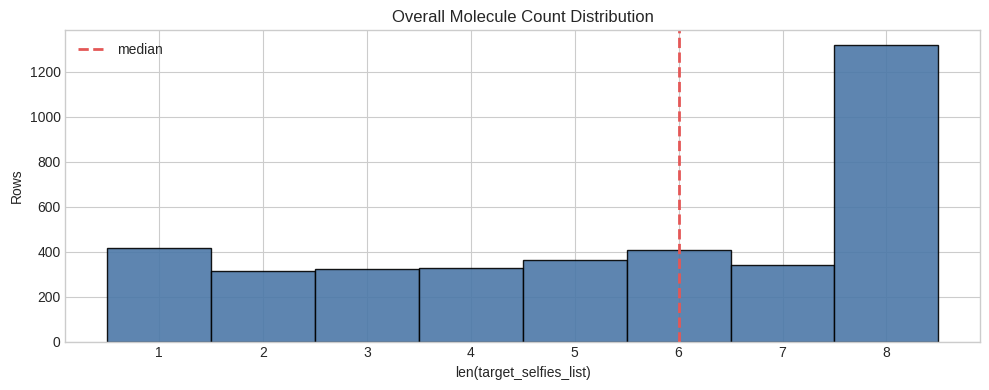

In [5]:
bins = integer_histogram_bins(length_df["molecule_count"])

fig, ax = plt.subplots(figsize=FIGSIZE_OVERALL)
ax.hist(
    length_df["molecule_count"],
    bins=bins,
    color="#4c78a8",
    edgecolor="black",
    alpha=0.9,
)
ax.axvline(length_df["molecule_count"].median(), color="#e45756", linestyle="--", linewidth=2, label="median")
ax.set_title("Overall Molecule Count Distribution")
ax.set_xlabel(f"len({MOLECULE_LIST_COLUMN})")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
plt.show()


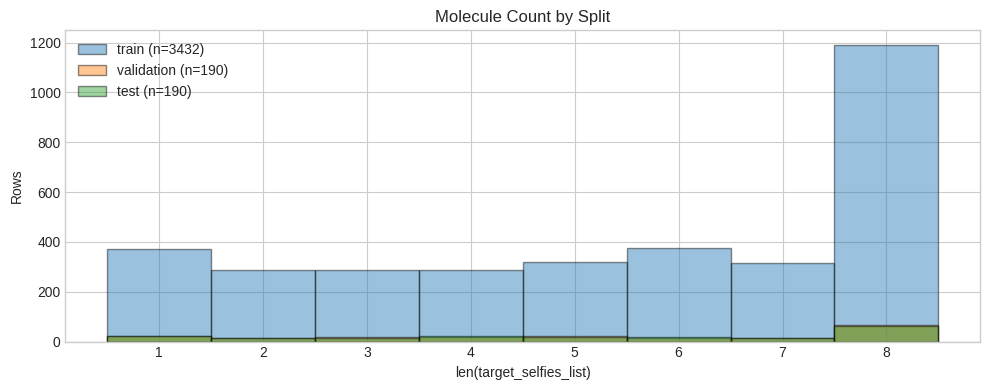

In [6]:
ordered_splits = sort_split_names(length_df["split"].unique())
bins = integer_histogram_bins(length_df["molecule_count"])

fig, ax = plt.subplots(figsize=FIGSIZE_SPLIT)
for split in ordered_splits:
    subset = length_df.loc[length_df["split"] == split, "molecule_count"]
    ax.hist(
        subset,
        bins=bins,
        alpha=0.45,
        edgecolor="black",
        label=f"{split} (n={len(subset)})",
    )

ax.set_title("Molecule Count by Split")
ax.set_xlabel(f"len({MOLECULE_LIST_COLUMN})")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
plt.show()
